In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Disha Sharma\Desktop\Paper_1\ModuleWise\BBB.csv")

print(df.shape)
print(df.columns.tolist())
df.head()

(5617, 46)
['code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result', 'date_registration', 'date_unregistration', 'ass_1_date', 'ass_1_score', 'ass_2_date', 'ass_2_score', 'ass_3_date', 'ass_3_score', 'ass_4_date', 'ass_4_score', 'ass_5_date', 'ass_5_score', 'ass_6_date', 'ass_6_score', 'ass_7_date', 'ass_7_score', 'ass_8_date', 'ass_8_score', 'ass_9_date', 'ass_9_score', 'ass_10_date', 'ass_10_score', 'ass_11_date', 'ass_11_score', 'clicks_forumng', 'clicks_glossary', 'clicks_homepage', 'clicks_oucollaborate', 'clicks_oucontent', 'clicks_ouelluminate', 'clicks_quiz', 'clicks_resource', 'clicks_sharedsubpage', 'clicks_subpage', 'clicks_url']


,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,...,clicks_glossary,clicks_homepage,clicks_oucollaborate,clicks_oucontent,clicks_ouelluminate,clicks_quiz,clicks_resource,clicks_sharedsubpage,clicks_subpage,clicks_url
0,2013B,23629,F,East Anglian Region,Lower Than A Level,20-30%,0-35,2,60,N,...,0.0,36.0,NaN,0.0,0.0,31.0,2.0,0.0,5.0,0.0
1,2013B,25107,F,East Anglian Region,Lower Than A Level,20-30%,0-35,0,120,N,...,2.0,831.0,NaN,1.0,1.0,85.0,23.0,0.0,21.0,14.0
2,2013B,27891,M,Scotland,Lower Than A Level,0-10%,0-35,2,120,Y,...,0.0,66.0,NaN,1.0,0.0,38.0,6.0,0.0,11.0,6.0
3,2013B,29144,M,South Region,Lower Than A Level,60-70%,0-35,0,120,N,...,2.0,556.0,NaN,3.0,0.0,78.0,358.0,0.0,442.0,39.0
4,2013B,31663,M,North Region,A Level or Equivalent,30-40%,35-55,0,60,N,...,3.0,1341.0,NaN,1.0,11.0,69.0,230.0,0.0,234.0,56.0


In [3]:
demographic_cols = ['gender', 'region', 'highest_education', 'imd_band', 'age_band',
                     'num_of_prev_attempts', 'studied_credits', 'disability']

assessment_cols = [f'ass_{i}_score' for i in range(1, 12)]

click_cols = ['clicks_forumng', 'clicks_glossary', 'clicks_homepage', 'clicks_oucollaborate',
              'clicks_oucontent', 'clicks_ouelluminate', 'clicks_quiz', 'clicks_resource',
              'clicks_sharedsubpage', 'clicks_subpage', 'clicks_url']

target_col = ['final_result']

selected_cols = demographic_cols + assessment_cols + click_cols + target_col
df_sel = df[selected_cols].copy()

print(df_sel.shape)
df_sel.head()

(5617, 31)


,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,ass_1_score,ass_2_score,...,clicks_homepage,clicks_oucollaborate,clicks_oucontent,clicks_ouelluminate,clicks_quiz,clicks_resource,clicks_sharedsubpage,clicks_subpage,clicks_url,final_result
0,F,East Anglian Region,Lower Than A Level,20-30%,0-35,2,60,N,67.0,63.0,...,36.0,NaN,0.0,0.0,31.0,2.0,0.0,5.0,0.0,Fail
1,F,East Anglian Region,Lower Than A Level,20-30%,0-35,0,120,N,59.0,60.0,...,831.0,NaN,1.0,1.0,85.0,23.0,0.0,21.0,14.0,Pass
2,M,Scotland,Lower Than A Level,0-10%,0-35,2,120,Y,73.0,67.0,...,66.0,NaN,1.0,0.0,38.0,6.0,0.0,11.0,6.0,Withdrawn
3,M,South Region,Lower Than A Level,60-70%,0-35,0,120,N,60.0,55.0,...,556.0,NaN,3.0,0.0,78.0,358.0,0.0,442.0,39.0,Fail
4,M,North Region,A Level or Equivalent,30-40%,35-55,0,60,N,88.0,80.0,...,1341.0,NaN,1.0,11.0,69.0,230.0,0.0,234.0,56.0,Pass


In [5]:
print(df_sel['imd_band'].unique())
print(df_sel['imd_band'].isna().sum())

['20-30%' '0-10%' '60-70%' '30-40%' '10-20' '70-80%' '50-60%' '40-50%'
 '80-90%' '90-100%' nan]
50


In [7]:
df_sel['imd_band'] = df_sel['imd_band'].replace('10-20', '10-20%')

mode_imd = df_sel['imd_band'].mode()[0]
df_sel['imd_band'] = df_sel['imd_band'].fillna(mode_imd)

print(df_sel['imd_band'].unique())
print(df_sel['imd_band'].isna().sum())
print(mode_imd)

['20-30%' '0-10%' '60-70%' '30-40%' '10-20%' '70-80%' '50-60%' '40-50%'
 '80-90%' '90-100%']
0
0-10%


In [9]:
assessment_cols = [f'ass_{i}_score' for i in range(1, 12)]
click_cols = ['clicks_forumng', 'clicks_glossary', 'clicks_homepage', 'clicks_oucollaborate',
              'clicks_oucontent', 'clicks_ouelluminate', 'clicks_quiz', 'clicks_resource',
              'clicks_sharedsubpage', 'clicks_subpage', 'clicks_url']

df_sel[assessment_cols] = df_sel[assessment_cols].fillna(-1)
df_sel[click_cols] = df_sel[click_cols].fillna(0)

print(df_sel[assessment_cols].isna().sum().sum())
print(df_sel[click_cols].isna().sum().sum())

0
0


In [11]:
from sklearn.preprocessing import LabelEncoder

# Ordinal: final_result
final_result_map = {'Withdrawn': 0, 'Fail': 1, 'Pass': 2, 'Distinction': 3}
df_sel['final_result'] = df_sel['final_result'].map(final_result_map)

# Ordinal: highest_education
highest_education_map = {
    'No Formal quals': 0,
    'Lower Than A Level': 1,
    'A Level or Equivalent': 2,
    'HE Qualification': 3,
    'Post Graduate Qualification': 4
}
df_sel['highest_education'] = df_sel['highest_education'].map(highest_education_map)

# Ordinal: imd_band
imd_band_map = {
    '0-10%': 0, '10-20%': 1, '20-30%': 2, '30-40%': 3, '40-50%': 4,
    '50-60%': 5, '60-70%': 6, '70-80%': 7, '80-90%': 8, '90-100%': 9
}
df_sel['imd_band'] = df_sel['imd_band'].map(imd_band_map)

# Ordinal: age_band
age_band_map = {'0-35': 0, '35-55': 1, '55<=': 2}
df_sel['age_band'] = df_sel['age_band'].map(age_band_map)

# Binary: gender, disability
df_sel['gender'] = df_sel['gender'].map({'F': 0, 'M': 1})
df_sel['disability'] = df_sel['disability'].map({'N': 0, 'Y': 1})

# Label encode: region
le = LabelEncoder()
df_sel['region'] = le.fit_transform(df_sel['region'])

print(df_sel.isna().sum().sum())
df_sel.dtypes

0


gender                    int64
region                    int64
highest_education         int64
imd_band                  int64
age_band                  int64
num_of_prev_attempts      int64
studied_credits           int64
disability                int64
ass_1_score             float64
ass_2_score             float64
ass_3_score             float64
ass_4_score             float64
ass_5_score             float64
ass_6_score             float64
ass_7_score             float64
ass_8_score             float64
ass_9_score             float64
ass_10_score            float64
ass_11_score            float64
clicks_forumng          float64
clicks_glossary         float64
clicks_homepage         float64
clicks_oucollaborate    float64
clicks_oucontent        float64
clicks_ouelluminate     float64
clicks_quiz             float64
clicks_resource         float64
clicks_sharedsubpage    float64
clicks_subpage          float64
clicks_url              float64
final_result              int64
dtype: o

In [13]:
click_cols = ['clicks_forumng', 'clicks_glossary', 'clicks_homepage', 'clicks_oucollaborate',
              'clicks_oucontent', 'clicks_ouelluminate', 'clicks_quiz', 'clicks_resource',
              'clicks_sharedsubpage', 'clicks_subpage', 'clicks_url']

for col in click_cols:
    print(col, '-> nonzero count:', (df_sel[col] > 0).sum(), '/ unique values:', df_sel[col].nunique())

clicks_forumng -> nonzero count: 4345 / unique values: 1183
clicks_glossary -> nonzero count: 1364 / unique values: 27
clicks_homepage -> nonzero count: 4686 / unique values: 732
clicks_oucollaborate -> nonzero count: 681 / unique values: 19
clicks_oucontent -> nonzero count: 3493 / unique values: 143
clicks_ouelluminate -> nonzero count: 451 / unique values: 23
clicks_quiz -> nonzero count: 4095 / unique values: 223
clicks_resource -> nonzero count: 4421 / unique values: 219
clicks_sharedsubpage -> nonzero count: 128 / unique values: 7
clicks_subpage -> nonzero count: 4553 / unique values: 273
clicks_url -> nonzero count: 4375 / unique values: 139


In [15]:
df_sel['total_clicks'] = df_sel[click_cols].sum(axis=1)
df_sel = df_sel.drop(columns=click_cols)

print(df_sel.shape)
print(df_sel['total_clicks'].describe())

(5617, 21)
count     5617.000000
mean       633.867189
std       1188.700871
min          0.000000
25%         47.000000
50%        298.000000
75%        719.000000
max      16440.000000
Name: total_clicks, dtype: float64


In [17]:
cols_to_bin = [f'ass_{i}_score' for i in range(1, 12)] + ['total_clicks']

for col in cols_to_bin:
    df_sel[col] = pd.qcut(df_sel[col], q=4, labels=False, duplicates='drop')

print(df_sel[cols_to_bin].nunique())
df_sel.head()

ass_1_score     4
ass_2_score     3
ass_3_score     3
ass_4_score     3
ass_5_score     3
ass_6_score     2
ass_7_score     2
ass_8_score     2
ass_9_score     2
ass_10_score    2
ass_11_score    1
total_clicks    4
dtype: int64


,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,ass_1_score,ass_2_score,...,ass_4_score,ass_5_score,ass_6_score,ass_7_score,ass_8_score,ass_9_score,ass_10_score,ass_11_score,final_result,total_clicks
0,0,0,1,2,0,2,60,0,1,0,...,0,0,0,1,1,0,0,0,1,1
1,0,0,1,2,0,0,120,0,1,0,...,1,1,0,1,1,1,1,0,2,3
2,1,6,1,0,0,2,120,1,2,1,...,0,0,0,1,0,0,0,0,0,2
3,1,8,1,6,0,0,120,0,1,0,...,1,1,0,1,1,0,1,0,1,3
4,1,4,2,3,1,0,60,0,3,2,...,1,1,0,1,0,1,1,0,2,3


In [19]:
for col in ['ass_6_score', 'ass_7_score', 'ass_8_score', 'ass_9_score', 'ass_10_score', 'ass_11_score']:
    print(col)
    print(df_sel_orig := None)  # placeholder, ignore

ass_6_score
None
ass_7_score
None
ass_8_score
None
ass_9_score
None
ass_10_score
None
ass_11_score
None


In [21]:
df_check = pd.read_csv(r"C:\Users\Disha Sharma\Desktop\Paper_1\ModuleWise\BBB.csv")[
    [f'ass_{i}_score' for i in range(6, 12)]
]
df_check = df_check.fillna(-1)

for col in df_check.columns:
    print(col)
    print(df_check[col].value_counts(bins=5))
    print('NaN/-1 count:', (df_check[col] == -1).sum(), '/', len(df_check))
    print()

ass_6_score
(-1.1019999999999999, 19.2]    3174
(59.6, 79.8]                   1123
(79.8, 100.0]                  1005
(39.4, 59.6]                    272
(19.2, 39.4]                     43
Name: count, dtype: int64
NaN/-1 count: 3144 / 5617

ass_7_score
(79.8, 100.0]                  3545
(-1.1019999999999999, 19.2]    1885
(59.6, 79.8]                    147
(39.4, 59.6]                     33
(19.2, 39.4]                      7
Name: count, dtype: int64
NaN/-1 count: 1884 / 5617

ass_8_score
(79.8, 100.0]                  2994
(-1.1019999999999999, 19.2]    2231
(59.6, 79.8]                    294
(39.4, 59.6]                     86
(19.2, 39.4]                     12
Name: count, dtype: int64
NaN/-1 count: 2224 / 5617

ass_9_score
(79.8, 100.0]                  2576
(-1.1019999999999999, 19.2]    2500
(59.6, 79.8]                    416
(39.4, 59.6]                    108
(19.2, 39.4]                     17
Name: count, dtype: int64
NaN/-1 count: 2497 / 5617

ass_10_score
(-1.101

In [23]:
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.PCUtils.BackgroundKnowledgeOrientUtils import BackgroundKnowledge

node_names = df_sel.columns.tolist()
data = df_sel.values

print(node_names)
print(data.shape)

['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'ass_1_score', 'ass_2_score', 'ass_3_score', 'ass_4_score', 'ass_5_score', 'ass_6_score', 'ass_7_score', 'ass_8_score', 'ass_9_score', 'ass_10_score', 'ass_11_score', 'final_result', 'total_clicks']
(5617, 21)


In [25]:
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.cit import chisq, gsq
from causallearn.graph.GraphNode import GraphNode
from causallearn.utils.PCUtils.BackgroundKnowledge import BackgroundKnowledge

nodes = [GraphNode(name) for name in node_names]
node_map = {name: node for name, node in zip(node_names, nodes)}

bk = BackgroundKnowledge()

demographics = ['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability']
course_time_vars = [f'ass_{i}_score' for i in range(1, 12)] + ['final_result', 'total_clicks']
protected_vars = ['studied_credits', 'num_of_prev_attempts']
assessment_cols = [f'ass_{i}_score' for i in range(1, 12)]

# Rule 1: course-time variables cannot cause demographics
for ct in course_time_vars:
    for d in demographics:
        bk.add_forbidden_by_node(node_map[ct], node_map[d])

# Rule 2: nothing can cause gender (exogenous root)
for n in node_names:
    if n != 'gender':
        bk.add_forbidden_by_node(node_map[n], node_map['gender'])

# Rule 3: assessments must respect sequential order (ass_j can't cause ass_i if j>i)
for i in range(1, 12):
    for j in range(i+1, 12):
        bk.add_forbidden_by_node(node_map[f'ass_{j}_score'], node_map[f'ass_{i}_score'])

# Rule 4: course-time variables cannot cause studied_credits/num_of_prev_attempts
for ct in course_time_vars:
    for p in protected_vars:
        bk.add_forbidden_by_node(node_map[ct], node_map[p])

# Rule 5: final_result cannot cause any assessment score
for a in assessment_cols:
    bk.add_forbidden_by_node(node_map['final_result'], node_map[a])

# Rule 6: assessment scores cannot cause total_clicks
for a in assessment_cols:
    bk.add_forbidden_by_node(node_map[a], node_map['total_clicks'])

cg = pc(data, alpha=0.05, indep_test=gsq, background_knowledge=bk, node_names=node_names)

print("Number of edges:", cg.G.get_num_edges())

  0%|          | 0/21 [00:00<?, ?it/s]

Number of edges: 51


In [27]:
edges = cg.G.get_graph_edges()
for edge in edges:
    print(edge)

gender --> age_band
highest_education --> region
region --> imd_band
age_band --> highest_education
disability --> highest_education
imd_band --- disability
age_band --> total_clicks
num_of_prev_attempts --- studied_credits
ass_1_score --> ass_2_score
ass_1_score --> ass_3_score
ass_1_score --> ass_4_score
ass_1_score --> ass_5_score
ass_1_score --> ass_7_score
ass_1_score --> ass_9_score
ass_1_score --> final_result
total_clicks --> ass_1_score
ass_2_score --> ass_3_score
ass_2_score --> ass_4_score
ass_2_score --> ass_5_score
ass_2_score --> ass_7_score
ass_2_score --> final_result
total_clicks --> ass_2_score
ass_3_score --> ass_4_score
ass_3_score --> ass_5_score
ass_3_score --> ass_6_score
ass_3_score --> ass_8_score
ass_3_score --> ass_9_score
ass_3_score --> final_result
total_clicks --> ass_3_score
ass_4_score --> ass_5_score
ass_4_score --> ass_6_score
ass_4_score --> ass_9_score
ass_4_score --> ass_10_score
ass_4_score --> final_result
ass_5_score --> ass_6_score
ass_5_score 

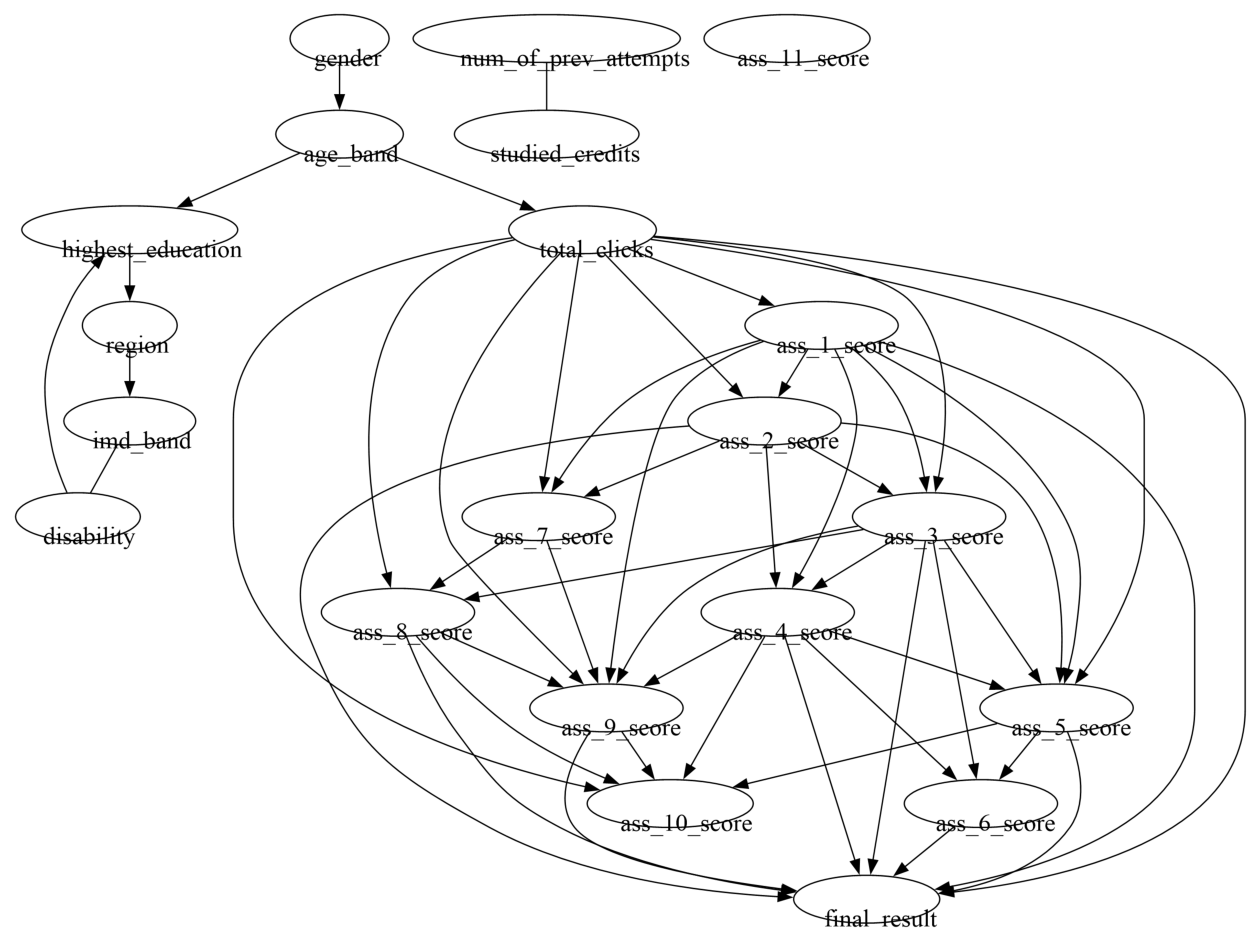

In [59]:
from causallearn.utils.GraphUtils import GraphUtils
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import io

dot_path = r"C:\Users\Disha Sharma\.conda\envs\analytics\Library\bin\dot.exe"

pyd = GraphUtils.to_pydot(cg.G, labels=node_names)
png_data = pyd.create_png(prog=dot_path)

img = mpimg.imread(io.BytesIO(png_data))
plt.figure(figsize=(16, 12))
plt.imshow(img)
plt.axis('off')
plt.show()

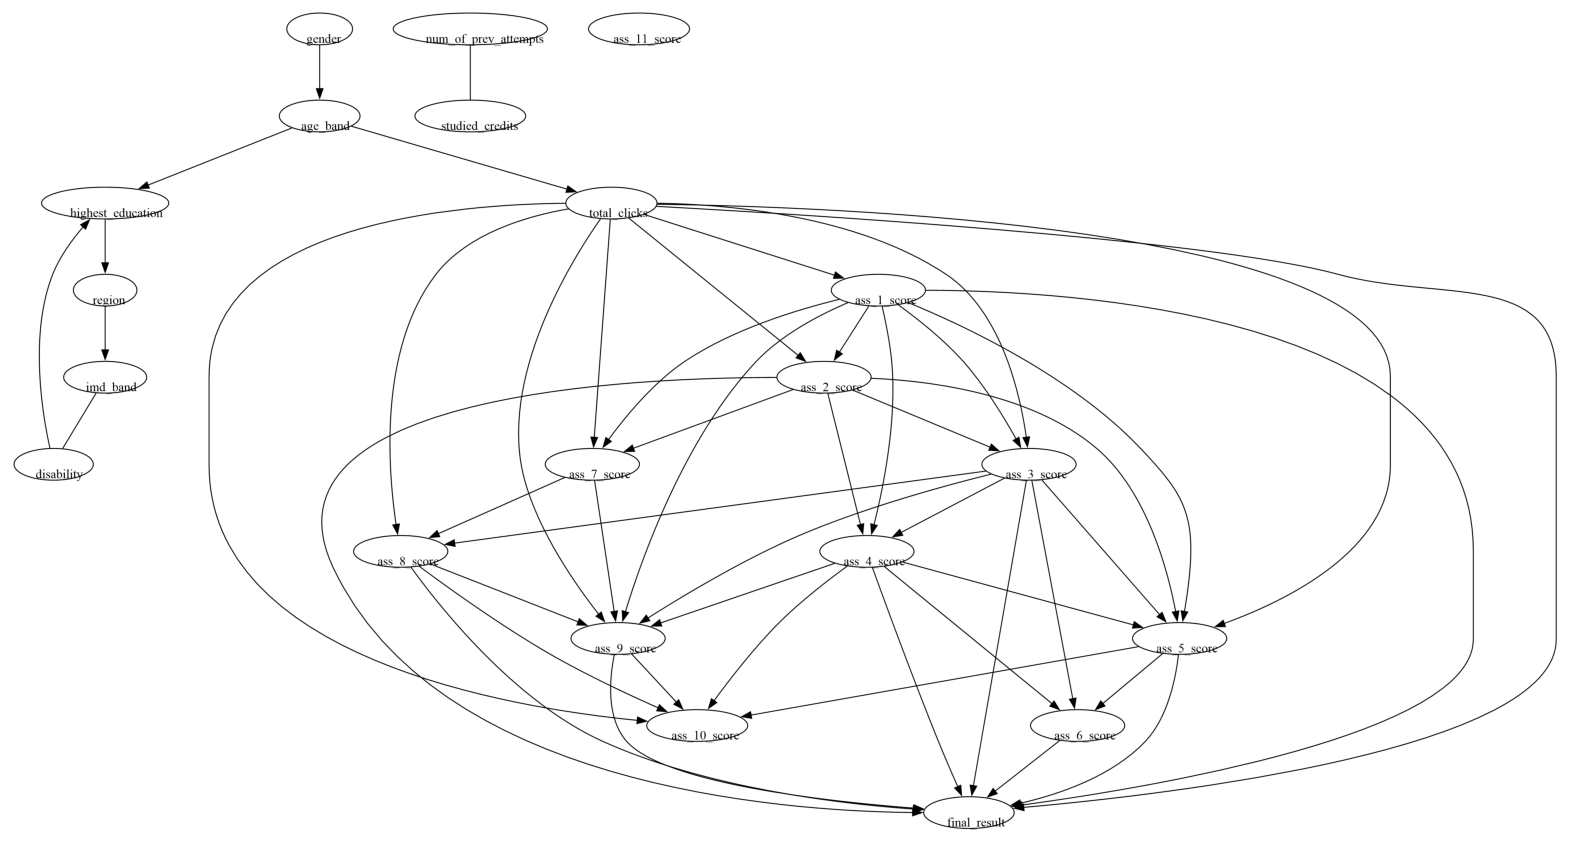

In [35]:
pyd = GraphUtils.to_pydot(cg.G, labels=node_names)

pyd.set_rankdir('TB')
pyd.set_nodesep(0.6)
pyd.set_ranksep(0.8)
pyd.set_splines('spline')

for node in pyd.get_nodes():
    node.set_fontsize('10')
    node.set_fixedsize('false')
    node.set_width('0.1')
    node.set_height('0.1')
    node.set_margin('0.15,0.08')

png_data = pyd.create_png(prog=dot_path)

img = mpimg.imread(io.BytesIO(png_data))
plt.figure(figsize=(20, 16))
plt.imshow(img)
plt.axis('off')
plt.show()

In [43]:
png_data = pyd.create_png(prog=dot_path)

with open(r"C:\Users\Disha Sharma\Desktop\Causal_AI\BBB_PC_graph.png", "wb") as f:
    f.write(png_data)

print("Saved")

Saved


# GES

In [51]:
from causallearn.search.ScoreBased.GES import ges

ges_result = ges(data, score_func='local_score_BDeu')

cg_ges = ges_result['G']
print("Number of edges (GES):", cg_ges.get_num_edges())

Number of edges (GES): 33


In [53]:
ges_edges = cg_ges.get_graph_edges()
for edge in ges_edges:
    print(edge)

X5 --> X1
X17 --> X1
X3 --- X8
X3 --- X20
X4 --- X18
X21 --> X5
X6 --- X13
X9 --> X10
X12 --> X9
X21 --> X9
X10 --> X11
X12 --> X10
X10 --> X15
X12 --> X11
X13 --> X11
X12 --- X13
X12 --- X14
X12 --- X17
X12 --- X18
X12 --- X20
X13 --- X14
X13 --- X18
X13 --- X20
X14 --- X20
X15 --> X16
X17 --> X15
X21 --> X15
X17 --> X16
X21 --> X16
X17 --- X18
X17 --> X21
X18 --> X21
X20 --> X21


In [55]:
idx_to_name = {i+1: name for i, name in enumerate(node_names)}

for edge in ges_edges:
    parts = str(edge).split()
    n1 = idx_to_name[int(parts[0][1:])]
    n2 = idx_to_name[int(parts[2][1:])]
    arrow = parts[1]
    print(f"{n1} {arrow} {n2}")

age_band --> gender
ass_9_score --> gender
highest_education --- disability
highest_education --- final_result
imd_band --- ass_10_score
total_clicks --> age_band
num_of_prev_attempts --- ass_5_score
ass_1_score --> ass_2_score
ass_4_score --> ass_1_score
total_clicks --> ass_1_score
ass_2_score --> ass_3_score
ass_4_score --> ass_2_score
ass_2_score --> ass_7_score
ass_4_score --> ass_3_score
ass_5_score --> ass_3_score
ass_4_score --- ass_5_score
ass_4_score --- ass_6_score
ass_4_score --- ass_9_score
ass_4_score --- ass_10_score
ass_4_score --- final_result
ass_5_score --- ass_6_score
ass_5_score --- ass_10_score
ass_5_score --- final_result
ass_6_score --- final_result
ass_7_score --> ass_8_score
ass_9_score --> ass_7_score
total_clicks --> ass_7_score
ass_9_score --> ass_8_score
total_clicks --> ass_8_score
ass_9_score --- ass_10_score
ass_9_score --> total_clicks
ass_10_score --> total_clicks
final_result --> total_clicks


In [57]:
import pydot

pyd_ges = pydot.Dot(graph_type='digraph')
pyd_ges.set_rankdir('TB')
pyd_ges.set_nodesep(0.5)
pyd_ges.set_ranksep(0.8)
pyd_ges.set_splines('spline')

for name in node_names:
    node = pydot.Node(name, fontsize='11', fixedsize='false', margin='0.15,0.08')
    pyd_ges.add_node(node)

for edge in ges_edges:
    parts = str(edge).split()
    n1 = idx_to_name[int(parts[0][1:])]
    n2 = idx_to_name[int(parts[2][1:])]
    arrow = parts[1]
    if arrow == '-->':
        pyd_ges.add_edge(pydot.Edge(n1, n2, dir='forward'))
    else:
        pyd_ges.add_edge(pydot.Edge(n1, n2, dir='none'))

png_data = pyd_ges.create_png(prog=dot_path)
with open(r"C:\Users\Disha Sharma\Desktop\Causal_AI\BBB_GES_graph.png", "wb") as f:
    f.write(png_data)

print("Saved")

Saved


# domain specific DAGs 

## Student info vs final_result

In [61]:
demo_cols_bbb = ['gender', 'region', 'highest_education', 'imd_band', 'age_band',
                  'disability', 'num_of_prev_attempts', 'studied_credits']

dag1_data_bbb = df_sel[demo_cols_bbb + ['final_result']].copy()

print(dag1_data_bbb.shape)
print(dag1_data_bbb.dtypes)

(5617, 9)
gender                  int64
region                  int64
highest_education       int64
imd_band                int64
age_band                int64
disability              int64
num_of_prev_attempts    int64
studied_credits         int64
final_result            int64
dtype: object


In [63]:
node_names_dag1_bbb = list(dag1_data_bbb.columns)
nodes_dag1_bbb = [GraphNode(name) for name in node_names_dag1_bbb]

bk1_bbb = BackgroundKnowledge()

gender_node_bbb = nodes_dag1_bbb[node_names_dag1_bbb.index('gender')]
final_result_node_bbb = nodes_dag1_bbb[node_names_dag1_bbb.index('final_result')]

# Rule 2: nothing causes gender (root)
for n in nodes_dag1_bbb:
    if n != gender_node_bbb:
        bk1_bbb.add_forbidden_by_node(n, gender_node_bbb)

# Rule 1 (generalized): final_result cannot cause any demographic
for n in nodes_dag1_bbb:
    if n != final_result_node_bbb:
        bk1_bbb.add_forbidden_by_node(final_result_node_bbb, n)

# Sanity check
highest_education_node_bbb = nodes_dag1_bbb[node_names_dag1_bbb.index('highest_education')]
print("highest_education -> gender forbidden:", bk1_bbb.is_forbidden(highest_education_node_bbb, gender_node_bbb))
print("final_result -> studied_credits forbidden:", bk1_bbb.is_forbidden(final_result_node_bbb, nodes_dag1_bbb[node_names_dag1_bbb.index('studied_credits')]))

highest_education -> gender forbidden: True
final_result -> studied_credits forbidden: True


In [65]:
data1_bbb = dag1_data_bbb.to_numpy()

cg1_bbb = pc(data1_bbb, alpha=0.05, indep_test='gsq', background_knowledge=bk1_bbb, node_names=node_names_dag1_bbb)

print("Number of edges:", cg1_bbb.G.get_num_edges())

  0%|          | 0/9 [00:00<?, ?it/s]

Number of edges: 13


In [67]:
for edge in cg1_bbb.G.get_graph_edges():
    node1 = edge.get_node1()
    node2 = edge.get_node2()
    ep1 = edge.get_endpoint1()
    ep2 = edge.get_endpoint2()
    print(f"{node1.get_name()} [{ep1}] -- [{ep2}] {node2.get_name()}")

gender [TAIL] -- [ARROW] age_band
highest_education [TAIL] -- [ARROW] region
imd_band [TAIL] -- [ARROW] region
age_band [TAIL] -- [ARROW] region
region [TAIL] -- [ARROW] final_result
highest_education [TAIL] -- [ARROW] imd_band
age_band [TAIL] -- [ARROW] highest_education
disability [TAIL] -- [ARROW] highest_education
highest_education [TAIL] -- [ARROW] final_result
imd_band [TAIL] -- [ARROW] final_result
age_band [TAIL] -- [ARROW] final_result
disability [TAIL] -- [TAIL] num_of_prev_attempts
num_of_prev_attempts [TAIL] -- [TAIL] studied_credits


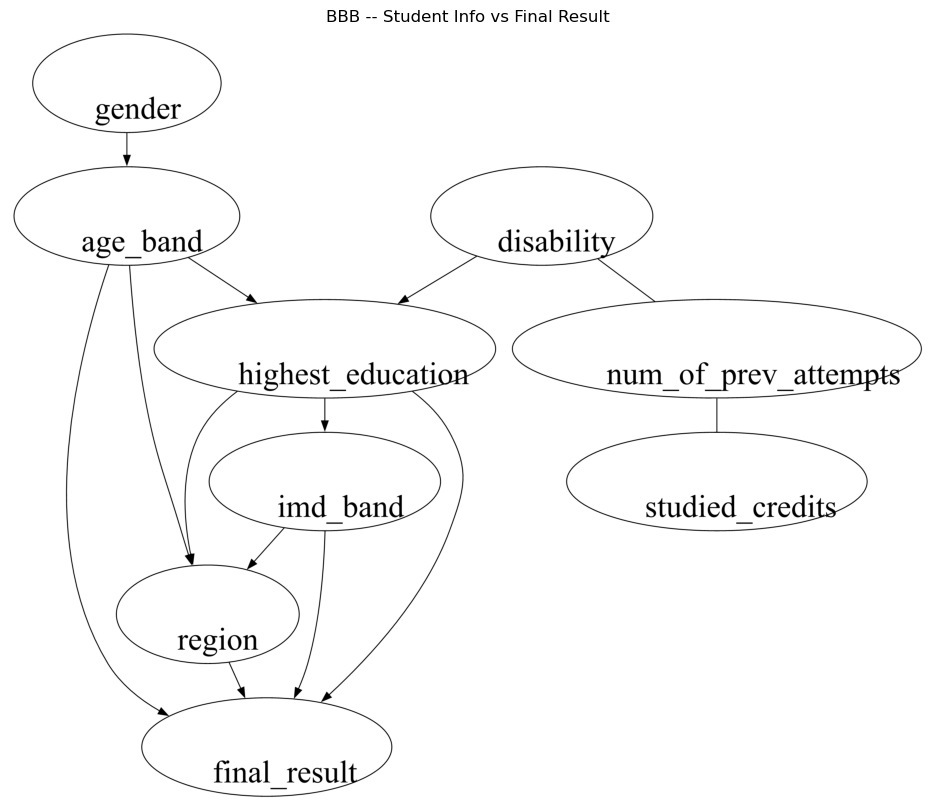

In [73]:
pyd1_bbb = GraphUtils.to_pydot(cg1_bbb.G, labels=node_names_dag1_bbb)

for node in pyd1_bbb.get_nodes():
    node.set_fontsize('25')
    node.set_fixedsize('false')
    node.set_margin('0.5,0.30')

png_bytes1_bbb = pyd1_bbb.create_png(prog=dot_path)

with open(r"C:\Users\Disha Sharma\Desktop\Paper_1\ModuleWise\BBB_DAG1_studentinfo_vs_finalresult.png", "wb") as f:
    f.write(png_bytes1_bbb)

img1_bbb = mpimg.imread(io.BytesIO(png_bytes1_bbb), format='png')
plt.figure(figsize=(12, 10))
plt.imshow(img1_bbb)
plt.axis('off')
plt.title("BBB -- Student Info vs Final Result")
plt.show()

## assessments vs final_result

In [75]:
ass_cols_bbb = [f'ass_{i}_score' for i in range(1, 12)]

dag2_data_bbb = df_sel[ass_cols_bbb + ['final_result']].copy()

print(dag2_data_bbb.shape)
print(dag2_data_bbb.dtypes)

(5617, 12)
ass_1_score     int64
ass_2_score     int64
ass_3_score     int64
ass_4_score     int64
ass_5_score     int64
ass_6_score     int64
ass_7_score     int64
ass_8_score     int64
ass_9_score     int64
ass_10_score    int64
ass_11_score    int64
final_result    int64
dtype: object


In [77]:
node_names_dag2_bbb = list(dag2_data_bbb.columns)
nodes_dag2_bbb = [GraphNode(name) for name in node_names_dag2_bbb]

bk2_bbb = BackgroundKnowledge()

final_result_node2_bbb = nodes_dag2_bbb[node_names_dag2_bbb.index('final_result')]

# Rule 5: final_result cannot cause any assessment
for n in nodes_dag2_bbb:
    if n != final_result_node2_bbb:
        bk2_bbb.add_forbidden_by_node(final_result_node2_bbb, n)

# Rule 3: sequential order -- ass_j cannot cause ass_i if j > i
for j in range(1, 12):
    for i in range(1, j):
        node_j = nodes_dag2_bbb[node_names_dag2_bbb.index(f'ass_{j}_score')]
        node_i = nodes_dag2_bbb[node_names_dag2_bbb.index(f'ass_{i}_score')]
        bk2_bbb.add_forbidden_by_node(node_j, node_i)

# Sanity check
ass1_node_bbb = nodes_dag2_bbb[node_names_dag2_bbb.index('ass_1_score')]
ass9_node_bbb = nodes_dag2_bbb[node_names_dag2_bbb.index('ass_9_score')]
print("ass_9 -> ass_1 forbidden:", bk2_bbb.is_forbidden(ass9_node_bbb, ass1_node_bbb))
print("final_result -> ass_1 forbidden:", bk2_bbb.is_forbidden(final_result_node2_bbb, ass1_node_bbb))

ass_9 -> ass_1 forbidden: True
final_result -> ass_1 forbidden: True


In [79]:
data2_bbb = dag2_data_bbb.to_numpy()

cg2_bbb = pc(data2_bbb, alpha=0.05, indep_test='gsq', background_knowledge=bk2_bbb, node_names=node_names_dag2_bbb)

print("Number of edges:", cg2_bbb.G.get_num_edges())

  0%|          | 0/12 [00:00<?, ?it/s]

Number of edges: 40


In [81]:
for edge in cg2_bbb.G.get_graph_edges():
    node1 = edge.get_node1()
    node2 = edge.get_node2()
    ep1 = edge.get_endpoint1()
    ep2 = edge.get_endpoint2()
    print(f"{node1.get_name()} [{ep1}] -- [{ep2}] {node2.get_name()}")

ass_1_score [TAIL] -- [ARROW] ass_2_score
ass_1_score [TAIL] -- [ARROW] ass_3_score
ass_1_score [TAIL] -- [ARROW] ass_4_score
ass_1_score [TAIL] -- [ARROW] ass_5_score
ass_1_score [TAIL] -- [ARROW] ass_7_score
ass_1_score [TAIL] -- [ARROW] ass_8_score
ass_1_score [TAIL] -- [ARROW] ass_9_score
ass_1_score [TAIL] -- [ARROW] ass_10_score
ass_1_score [TAIL] -- [ARROW] final_result
ass_2_score [TAIL] -- [ARROW] ass_3_score
ass_2_score [TAIL] -- [ARROW] ass_4_score
ass_2_score [TAIL] -- [ARROW] ass_5_score
ass_2_score [TAIL] -- [ARROW] ass_7_score
ass_2_score [TAIL] -- [ARROW] ass_8_score
ass_2_score [TAIL] -- [ARROW] final_result
ass_3_score [TAIL] -- [ARROW] ass_4_score
ass_3_score [TAIL] -- [ARROW] ass_5_score
ass_3_score [TAIL] -- [ARROW] ass_6_score
ass_3_score [TAIL] -- [ARROW] ass_7_score
ass_3_score [TAIL] -- [ARROW] ass_8_score
ass_3_score [TAIL] -- [ARROW] ass_9_score
ass_3_score [TAIL] -- [ARROW] final_result
ass_4_score [TAIL] -- [ARROW] ass_5_score
ass_4_score [TAIL] -- [ARROW] 

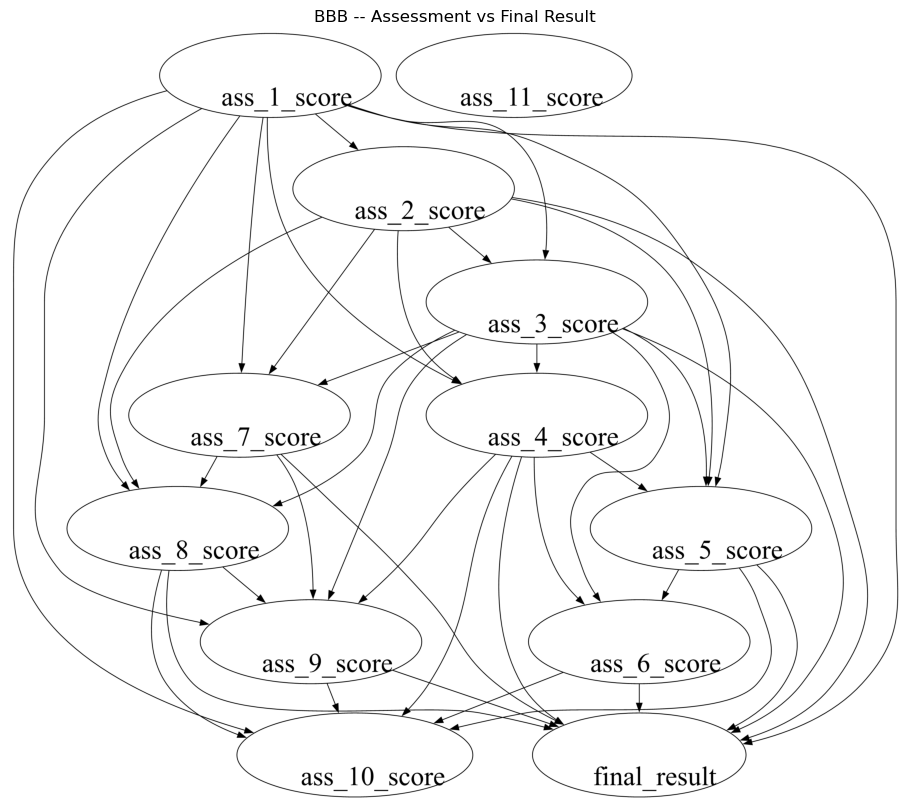

In [99]:
pyd1_bbb = GraphUtils.to_pydot(cg2_bbb.G, labels=node_names_dag2_bbb)

for node in pyd1_bbb.get_nodes():
    node.set_fontsize('25')
    node.set_fixedsize('false')
    node.set_margin('0.5,0.30')

png_bytes1_bbb = pyd1_bbb.create_png(prog=dot_path)

with open(r"C:\Users\Disha Sharma\Desktop\Paper_1\ModuleWise\BBB_DAG2_assessment_vs_finalresult.png", "wb") as f:
    f.write(png_bytes1_bbb)

img1_bbb = mpimg.imread(io.BytesIO(png_bytes1_bbb), format='png')
plt.figure(figsize=(12, 10))
plt.imshow(img1_bbb)
plt.axis('off')
plt.title("BBB -- Assessment vs Final Result")
plt.show()

## individual clicks vs final_result

In [85]:
raw_click_cols_bbb = ['clicks_forumng', 'clicks_glossary', 'clicks_homepage', 'clicks_oucollaborate',
                       'clicks_oucontent', 'clicks_ouelluminate', 'clicks_quiz', 'clicks_resource',
                       'clicks_sharedsubpage', 'clicks_subpage', 'clicks_url']

clicks_raw_bbb = df[raw_click_cols_bbb].fillna(0)

for col in raw_click_cols_bbb:
    print(col, "nonzero:", (clicks_raw_bbb[col] > 0).sum(), "unique:", clicks_raw_bbb[col].nunique())

clicks_forumng nonzero: 4345 unique: 1183
clicks_glossary nonzero: 1364 unique: 27
clicks_homepage nonzero: 4686 unique: 732
clicks_oucollaborate nonzero: 681 unique: 19
clicks_oucontent nonzero: 3493 unique: 143
clicks_ouelluminate nonzero: 451 unique: 23
clicks_quiz nonzero: 4095 unique: 223
clicks_resource nonzero: 4421 unique: 219
clicks_sharedsubpage nonzero: 128 unique: 7
clicks_subpage nonzero: 4553 unique: 273
clicks_url nonzero: 4375 unique: 139


In [87]:
dag3_data_bbb = clicks_raw_bbb.copy()

for col in raw_click_cols_bbb:
    dag3_data_bbb[col] = pd.qcut(dag3_data_bbb[col], q=4, labels=False, duplicates='drop')

dag3_data_bbb['final_result'] = df_sel['final_result'].values

print(dag3_data_bbb.shape)
for col in dag3_data_bbb.columns:
    print(col, dag3_data_bbb[col].nunique())

(5617, 12)
clicks_forumng 4
clicks_glossary 1
clicks_homepage 4
clicks_oucollaborate 1
clicks_oucontent 3
clicks_ouelluminate 1
clicks_quiz 3
clicks_resource 4
clicks_sharedsubpage 1
clicks_subpage 4
clicks_url 4
final_result 4


In [89]:
node_names_dag3_bbb = list(dag3_data_bbb.columns)
nodes_dag3_bbb = [GraphNode(name) for name in node_names_dag3_bbb]

bk3_bbb = BackgroundKnowledge()

final_result_node3_bbb = nodes_dag3_bbb[node_names_dag3_bbb.index('final_result')]

# Rule 6 (per-column): final_result cannot cause any individual click variable
for n in nodes_dag3_bbb:
    if n != final_result_node3_bbb:
        bk3_bbb.add_forbidden_by_node(final_result_node3_bbb, n)

# Sanity check
clicks_resource_node_bbb = nodes_dag3_bbb[node_names_dag3_bbb.index('clicks_resource')]
print("final_result -> clicks_resource forbidden:", bk3_bbb.is_forbidden(final_result_node3_bbb, clicks_resource_node_bbb))

final_result -> clicks_resource forbidden: True


In [91]:
data3_bbb = dag3_data_bbb.to_numpy()

cg3_bbb = pc(data3_bbb, alpha=0.05, indep_test='gsq', background_knowledge=bk3_bbb, node_names=node_names_dag3_bbb)

print("Number of edges:", cg3_bbb.G.get_num_edges())

  0%|          | 0/12 [00:00<?, ?it/s]

Number of edges: 22


In [93]:
for edge in cg3_bbb.G.get_graph_edges():
    node1 = edge.get_node1()
    node2 = edge.get_node2()
    ep1 = edge.get_endpoint1()
    ep2 = edge.get_endpoint2()
    print(f"{node1.get_name()} [{ep1}] -- [{ep2}] {node2.get_name()}")

clicks_homepage [TAIL] -- [ARROW] clicks_forumng
clicks_forumng [TAIL] -- [ARROW] clicks_oucontent
clicks_resource [TAIL] -- [ARROW] clicks_forumng
clicks_url [TAIL] -- [ARROW] clicks_forumng
clicks_forumng [TAIL] -- [ARROW] final_result
clicks_homepage [TAIL] -- [ARROW] clicks_oucontent
clicks_homepage [TAIL] -- [TAIL] clicks_quiz
clicks_homepage [TAIL] -- [ARROW] clicks_resource
clicks_homepage [TAIL] -- [ARROW] clicks_subpage
clicks_homepage [TAIL] -- [TAIL] clicks_url
clicks_homepage [TAIL] -- [ARROW] final_result
clicks_quiz [TAIL] -- [ARROW] clicks_oucontent
clicks_resource [TAIL] -- [ARROW] clicks_oucontent
clicks_subpage [TAIL] -- [ARROW] clicks_oucontent
clicks_url [TAIL] -- [ARROW] clicks_oucontent
clicks_oucontent [TAIL] -- [ARROW] final_result
clicks_quiz [TAIL] -- [ARROW] clicks_subpage
clicks_quiz [TAIL] -- [ARROW] final_result
clicks_subpage [TAIL] -- [ARROW] clicks_resource
clicks_url [TAIL] -- [ARROW] clicks_resource
clicks_url [TAIL] -- [ARROW] clicks_subpage
clicks_u

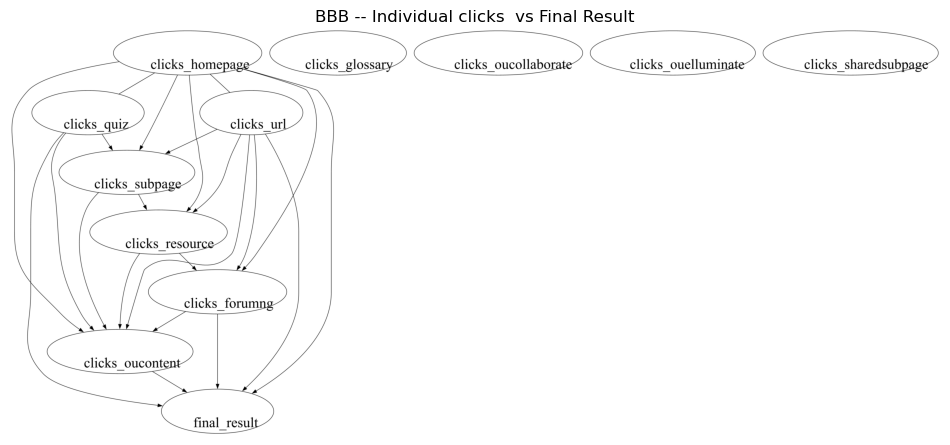

In [103]:
pyd1_bbb = GraphUtils.to_pydot(cg3_bbb.G, labels=node_names_dag3_bbb)

for node in pyd1_bbb.get_nodes():
    node.set_fontsize('25')
    node.set_fixedsize('false')
    node.set_margin('0.5,0.30')

png_bytes1_bbb = pyd1_bbb.create_png(prog=dot_path)

with open(r"C:\Users\Disha Sharma\Desktop\Paper_1\ModuleWise\BBB_DAG3_clicks_vs_finalresult.png", "wb") as f:
    f.write(png_bytes1_bbb)

img1_bbb = mpimg.imread(io.BytesIO(png_bytes1_bbb), format='png')
plt.figure(figsize=(12, 10))
plt.imshow(img1_bbb)
plt.axis('off')
plt.title("BBB -- Individual clicks  vs Final Result")
plt.show()